In [34]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import UnivariateSpline
from astropy.table import Table
from cosmology import cosmo
import catalogue_analysis as ca
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [6]:
# Configure
rsphere = 1600  #Mpc/h

In [2]:
# Target comoving density to match random catalogue
reg='N'
rancat=rf"./sdata/Mocks/rancat2ndSep_fordata_{reg}.fits"
ran=Table.read(rancat)
print('Completed reading random catalogue.')
if 'fordata' in rancat:
    Sel=ca.selection(reg)
    fsky=Sel['area']
else:
    fsky=ran.meta['FSKY']

NMULT=ran.meta['NMULT']
print(rf"sky={fsky:.4f} NMULT={NMULT}")
ran['dist']=ca.cosmo.comoving_distance(ran['Z']).value  # Mpc/h

#ran.info('stats')

Completed reading random catalogue.
sky=0.0928 NMULT=9.146734351287305


In [3]:
# Estimate density in spherical shells taking account of the fraction of sky covered by the random catalogue and its oversampling factor
# distance bins
rbins = np.linspace(0.0, 1600.0, 81)  # 20 Mpc bins
rcen = 0.5 * (rbins[1:] + rbins[:-1])

# Count objects in each shell
counts, _ = np.histogram(ran['dist'], bins=rbins)

# Shell volumes
volumes = fsky * (4.0 / 3.0) * np.pi * (rbins[1:]**3 - rbins[:-1]**3)

# Density
density = (counts/NMULT) / volumes


In [4]:
# Define function that fits the upper envelope of the density

good = density > 3e-5

spl = UnivariateSpline(
    rcen[good],
    np.log10(density[good]),
    s=0.02
)

resid = np.log10(density[good]) - spl(rcen[good])
offset = resid.max() + 0.02

r_flat = 50.0   # Mpc

logn0 = spl(r_flat) + offset

def nden(r):

    r = np.asarray(r)

    logn = spl(r) + offset

    # Hold constant below r_flat
    logn = np.where(r < r_flat, logn0, logn)

    return 10.0**logn

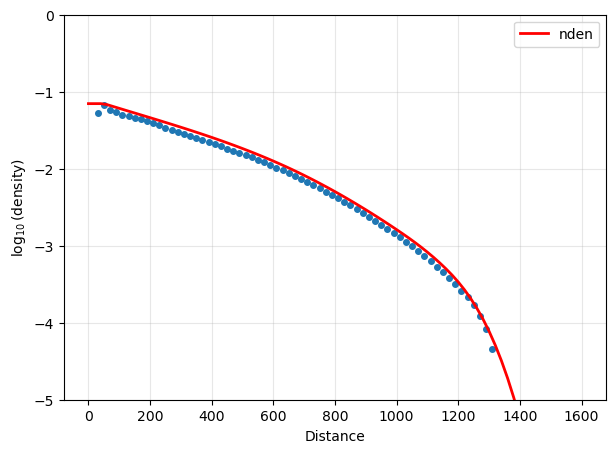

In [9]:
# Plot the density estimated from the random catalogue and the function that provides an envelope to it
mask = density > 0


plt.figure(figsize=(7,5))
plt.plot(rcen[mask], np.log10(density[mask]), 'o', ms=4)
plt.plot(rbins,
         np.log10(nden(rbins)),
         'r-', lw=2,label='nden')
plt.xlabel('Distance')
plt.ylabel(r'$\log_{10}(\mathrm{density})$')
plt.grid(alpha=0.3)
plt.legend()
plt.ylim([-5,0])
plt.show()


In [25]:
#Determine the cumulative number density to radius r and set up the inverse function to give the radius
#corresponding to fraction u of the cumulative density

rmax = rsphere

# Radial grid for inverse transform sampling
r_grid = np.linspace(0.0, rmax, 100000)

nb_grid = nden(r_grid)

# cumulative expected number
integrand = 4.0 * np.pi * r_grid**2 * nb_grid

dr = np.diff(r_grid)

cum_num = np.zeros_like(r_grid)
cum_num[1:] = np.cumsum(
    0.5 * (integrand[:-1] + integrand[1:]) * dr
)

N =  np.rint(cum_num[-1]).astype(int)
print('Total number expected within the sphere',N)
# Normalize by total cumulative density
cum_num /= cum_num[-1]

# inverse CDF
r_of_u = interp1d(
    cum_num,
    r_grid,
    bounds_error=False,
    fill_value=(0.0, rmax)
)

Total number expected within the sphere 39688201


In [26]:
# Generate random points in sphere with this chosen density profile.

#N = 10_000_000

u = np.random.random(N)
r = r_of_u(u)

cos_theta = np.random.uniform(-1.0, 1.0, N)
sin_theta = np.sqrt(1.0 - cos_theta**2)

phi = np.random.uniform(0.0, 2.0*np.pi, N)

x = r * sin_theta * np.cos(phi)
y = r * sin_theta * np.sin(phi)
z = r * cos_theta


In [27]:
#Set up the subhalos table
subhalos = Table()

subhalos['x'] = x
subhalos['y'] = y
subhalos['z'] = z

subhalos['dist'] = r

subhalos['DEC'] = np.degrees(
    np.arcsin(z/r)
)

subhalos['RA'] = (
    np.degrees(np.arctan2(y, x))
) % 360

subhalos['Mpeak_Scale'] = np.random.random(N)
subhalos['Vpeak']       = np.random.random(N)
subhalos['Mvir_all']    = np.random.random(N)
subhalos['FracZpeak']   = np.random.random(N)

In [28]:
z_grid = np.linspace(0.0, 1.0, 10000)

Dc_grid = ca.cosmo.comoving_distance(
    z_grid
).value

z_of_Dc = interp1d(
    Dc_grid,
    z_grid,
    bounds_error=False,
    fill_value="extrapolate"
)

subhalos['Zu'] = z_of_Dc(subhalos['dist'])

In [29]:
nden0=nden(0.0)
p = nden(subhalos['dist']) / nden0

mark = -np.log(
    np.random.random(N)
) / p

order = np.argsort(mark)

i = np.empty(N, dtype=np.int64)
i[order] = np.arange(1, N+1)

subhalos['i'] = i

In [30]:
subhalos.write('sdata/uniform_subhalos.fits',overwrite=True)

OSError: File sdata/uniform_subhalos.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [31]:
# Estimate density of points in radial shells of the generated uniform subhalo catalogue

# Count objects in each shell
counts, _ = np.histogram(subhalos['dist'], bins=rbins)

# Shell volumes
volumes =  (4.0 / 3.0) * np.pi * (rbins[1:]**3 - rbins[:-1]**3)

# Density
density_subs = (counts) / volumes

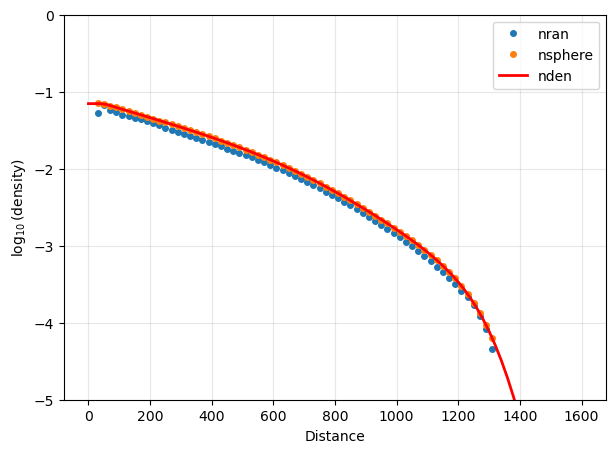

In [33]:
# Plot the density estimated from the random catalogue and the function that provides an envelope to it
mask = density > 0


plt.figure(figsize=(7,5))
plt.plot(rcen[mask], np.log10(density[mask]), 'o', ms=4,label='nran')
plt.plot(rcen[mask], np.log10(density_subs[mask]), 'o', ms=4,label='nsphere')
plt.plot(rbins,
         np.log10(nden(rbins)),
         'r-', lw=2,label='nden')
plt.xlabel('Distance')
plt.ylabel(r'$\log_{10}(\mathrm{density})$')
plt.grid(alpha=0.3)
plt.legend()
plt.ylim([-5,0])
plt.show()


In [41]:
def Mstar(z):
    Mstar= -21 - 0.78*(z-0.1)
    return Mstar
alpha=-1.2
phi_star=1.2e-02

In [42]:
def schechter_mag(M, Mstar, alpha, phi_star):

    x = 10.0**(0.4*(Mstar - M))

    return (
        0.4*np.log(10.0)
        * phi_star
        * x**(alpha + 1.0)
        * np.exp(-x)
    )

In [43]:
def make_clf_inverse(Mstar_z, alpha, phi_star,
                     Mbright=-24.0,
                     Mfaint=-10.0):

    Mgrid = np.linspace(Mbright, Mfaint, 5000)

    phi = schechter_mag(
        Mgrid,
        Mstar_z,
        alpha,
        phi_star
    )

    clf = cumulative_trapezoid(phi, Mgrid, initial=0)

    clf /= clf[-1]

    return interp1d(
        clf,
        Mgrid,
        bounds_error=False,
        fill_value=(Mbright, Mfaint)
    )

In [44]:
#Within each redshift slice, rank the objects and map those ranks onto the local Schechter LF.

subhalos['Mr'] = np.nan
zbins=np.linspace(0,0.5,1000)

for zlo, zhi in zip(zbins[:-1], zbins[1:]):

    m = (
        (subhalos['Zu'] >= zlo)
        &
        (subhalos['Zu'] < zhi)
    )

    idx = np.where(m)[0]

    if len(idx) == 0:
        continue

    zmid = 0.5*(zlo + zhi)

    inv_clf = make_clf_inverse(
        Mstar(zmid),
        alpha,
        phi_star
    )

    order = np.argsort(subhalos['i'][idx])

    u = (np.arange(len(idx)) + 0.5)/len(idx)

    M = inv_clf(u)

    subhalos['Mr'][idx[order]] = M

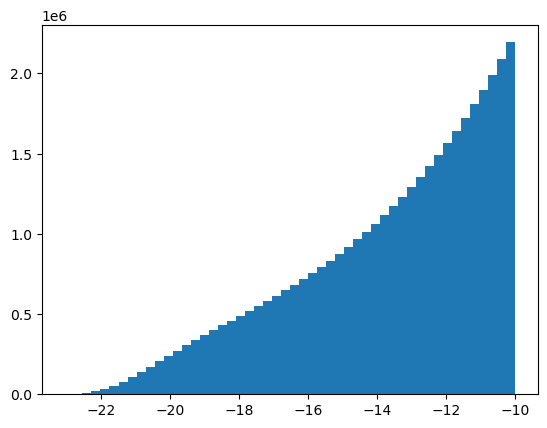

In [50]:
zlo = 0*4
zhi = 0.5

m = (subhalos['Zu'] >= zlo) & (subhalos['Zu'] < zhi)

plt.hist(subhalos['Mr'][m], bins=50)
zmid = 0.45

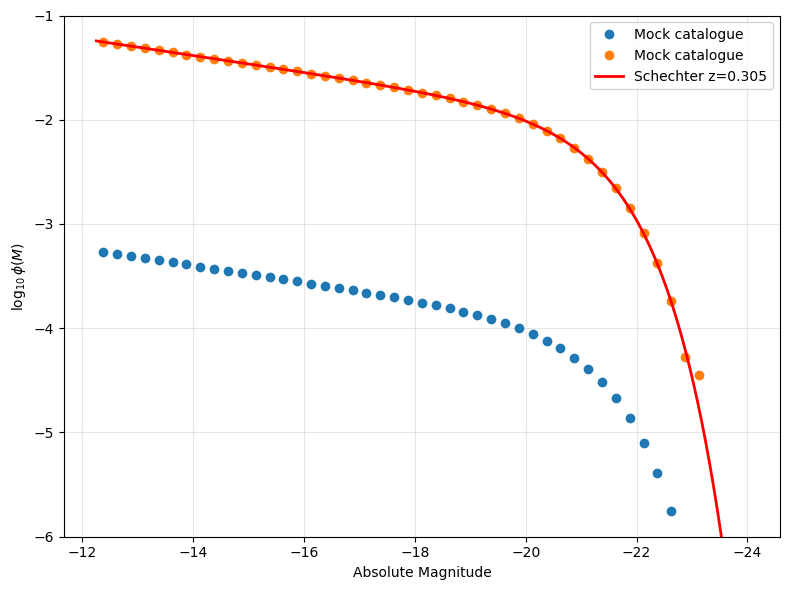

In [58]:


# -------------------------------------------------------
# Select a distance shell
# -------------------------------------------------------

rlo = 800.0
rhi = 900.0

m = (
    (subhalos['dist'] >= rlo) &
    (subhalos['dist'] <  rhi)
)

M = subhalos['Mr'][m]

# -------------------------------------------------------
# Comoving shell volume
# -------------------------------------------------------

Vshell = (4.0/3.0)*np.pi*(rhi**3 - rlo**3)

# -------------------------------------------------------
# Estimate luminosity function
# -------------------------------------------------------

Mbins = np.arange(-24.0, -12.0, 0.25)

counts, edges = np.histogram(M, bins=Mbins)

Mcen = 0.5*(edges[:-1] + edges[1:])
dM = edges[1] - edges[0]

# number density per magnitude
phi_est = counts / (Vshell * dM)

# -------------------------------------------------------
# Schechter prediction
# -------------------------------------------------------

zmid = np.median(subhalos['Zu'][m])

Mplot = np.linspace(Mbins[0], Mbins[-1], 1000)

phi_model = schechter_mag(
    Mplot,
    Mstar(zmid),
    alpha,
    phi_star
)

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

good = phi_est > 0

plt.figure(figsize=(8,6))

plt.plot(
    Mcen[good],
    np.log10(phi_est[good]),
    'o',
    label='Mock catalogue'
)

plt.plot(
    Mcen[good],
    np.log10(phi_est[good]/ratio),
    'o',
    label='Mock catalogue'
)

plt.plot(
    Mplot,
    np.log10(phi_model),
    'r-',
    lw=2,
    label=f'Schechter z={zmid:.3f}'
)

plt.xlabel('Absolute Magnitude')
plt.ylabel(r'$\log_{10}\phi(M)$')
plt.legend()
plt.grid(alpha=0.3)

# optional astronomy convention:
plt.gca().invert_xaxis()
plt.ylim([-6,-1])
plt.tight_layout()
plt.show()

In [57]:
n_sub = np.sum(m) / Vshell

print(n_sub)

from scipy.integrate import quad

Mbright=-24
Mfaint=-10

n_lf, err = quad(
    lambda M: schechter_mag(
        M,
        Mstar(zmid),
        alpha,
        phi_star
    ),
    Mbright,
    Mfaint
)

print(n_lf)

ratio=n_sub / n_lf

0.003863529882814349
0.39889583917241456
